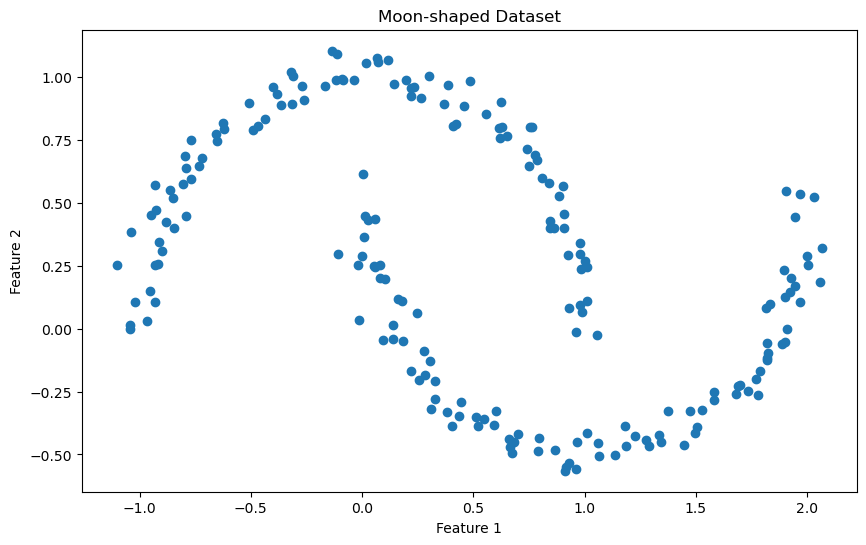

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

X, _ = make_moons(n_samples=200, noise=0.05, random_state=42)
# Visualize the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.title('Moon-shaped Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

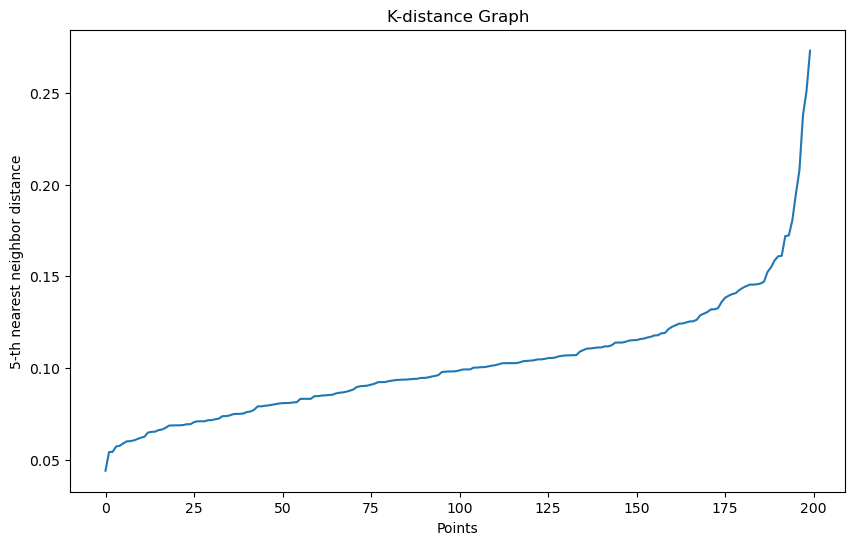

In [6]:
# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k=5)


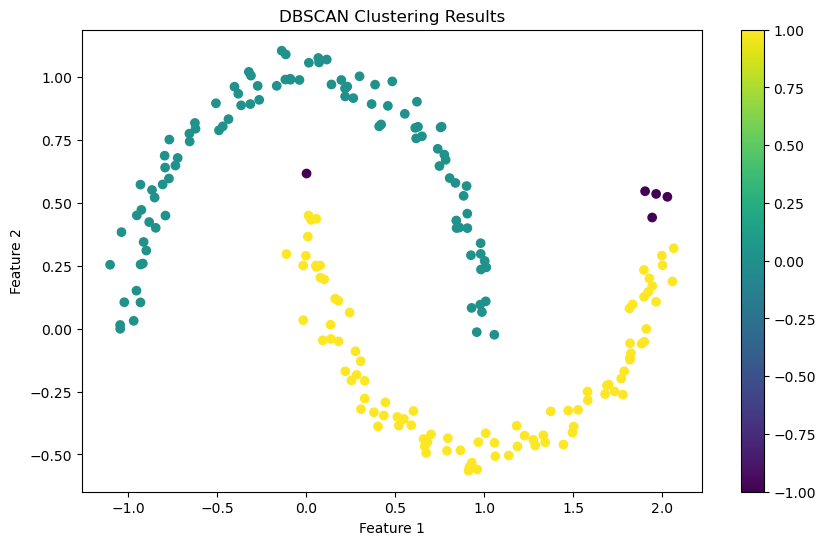

In [5]:

# Perform DBSCAN clustering
epsilon = 0.15  # Chosen based on k-distance graph
min_samples = 5  # 2 * num_features (2D data)
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
clusters = dbscan.fit_predict(X)

# Visualize the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.colorbar(scatter)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [7]:
# Print number of clusters and noise points
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
print(f'Number of clusters: {n_clusters}')
print(f'Number of noise points: {n_noise}')

Number of clusters: 2
Number of noise points: 5


C:\Users\Aditya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


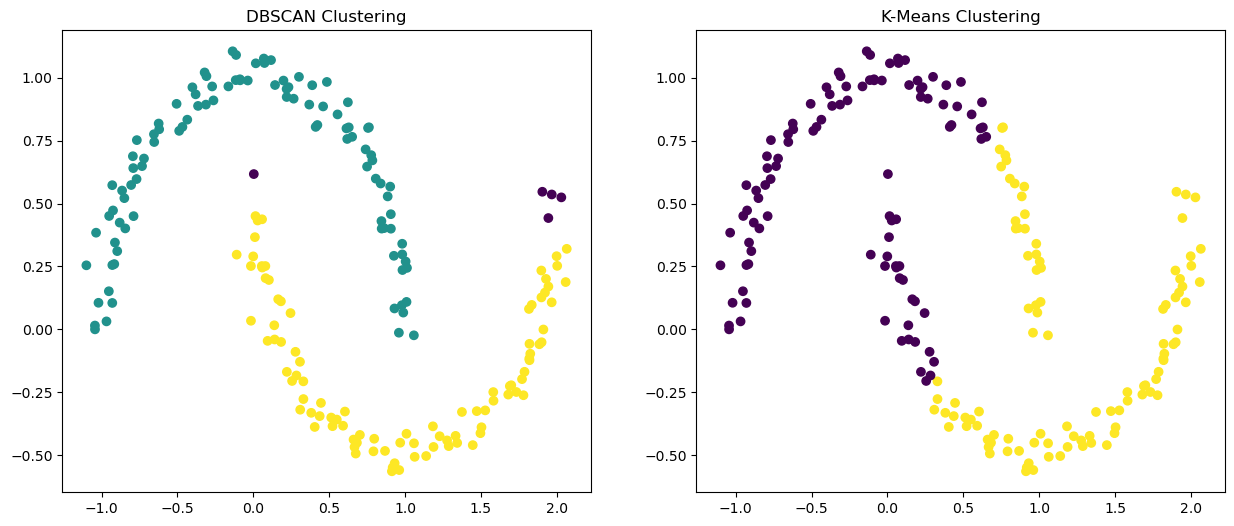

In [8]:
from sklearn.cluster import KMeans

# DBSCAN clustering
dbscan = DBSCAN(eps=0.15, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis')
ax1.set_title('DBSCAN Clustering')

ax2.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
ax2.set_title('K-Means Clustering')

plt.show()


Customer Data:
    Spend_Per_Visit  Visit_Frequency
0              5000               50
1              5200               48
2              4800               52
3              1500               10
4              1600               12
5              1400                9
6              3000               25
7              3100               27
8              2900               24
9              8000                5
10              200                2

Clustered Data:
    Spend_Per_Visit  Visit_Frequency  Cluster
0              5000               50        0
1              5200               48        0
2              4800               52        0
3              1500               10        1
4              1600               12        1
5              1400                9        1
6              3000               25        2
7              3100               27        2
8              2900               24        2
9              8000                5       -1
10              20

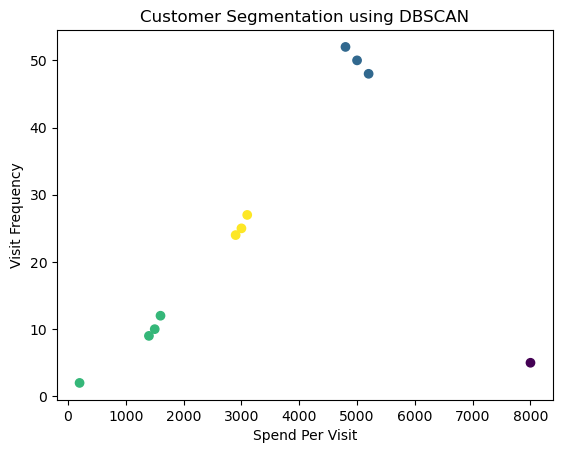

In [15]:
# Scenario: Customer Segmentation for a Retail Store
# Context:
# A retail store wants to understand its customers better. 
# They have data on how much each customer spends per visit and how frequently they visit the store. 
# The goal is to group customers into clusters (e.g., “loyal high spenders,” “occasional visitors,” etc.) using DBSCAN,
# which is great for finding clusters of varying shapes and identifying outliers.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Customer data: [Spend_Per_Visit, Visit_Frequency]
data = np.array([
    [5000, 50], [5200, 48], [4800, 52],   # Loyal high spenders
    [1500, 10], [1600, 12], [1400, 9],    # Occasional visitors
    [3000, 25], [3100, 27], [2900, 24],   # Moderate spenders
    [8000, 5],                            # Outlier: rare but huge spender
    [200, 2],                             # Outlier: very low engagement
])

# Create DataFrame with column names
df = pd.DataFrame(data, columns=["Spend_Per_Visit", "Visit_Frequency"])

print("Customer Data:")
print(df)

# # Feature Scaling
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(df)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=2)
clusters = dbscan.fit_predict(scaled_data)

# Add cluster labels
df["Cluster"] = clusters

print("\nClustered Data:")
print(df)

# Plot clusters
plt.scatter(df["Spend_Per_Visit"], df["Visit_Frequency"], c=df["Cluster"])

plt.xlabel("Spend Per Visit")
plt.ylabel("Visit Frequency")
plt.title("Customer Segmentation using DBSCAN")

plt.show()

In [ ]:
# Scenario: Fine‑tune ResNet‑50 for Music Genre Classification
# Context:
# A streaming service wants to automatically classify songs into genres (e.g., rock, jazz, classical, hip‑hop, electronic). They have 4,000 audio tracks labeled by genre. Instead of training from scratch, they’ll fine‑tune a ResNet‑50 pretrained on ImageNet, but adapted to work with spectrogram images of audio.

# 📊 Dataset
# - Convert each audio track into a Mel‑spectrogram (visual representation of sound frequencies over time).
# - Each spectrogram is treated like an image (RGB channels).
# - Dataset: 4,000 spectrograms across 5 genres.


# Fine-tune ResNet-50 for Music Genre Classification

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models, datasets
from torch.utils.data import DataLoader, random_split

# -----------------------------
# Image Transformations
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),      # ResNet input size
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# -----------------------------
# Load Spectrogram Dataset
# -----------------------------
dataset = datasets.ImageFolder(root="dataset", transform=transform)

print("Classes:", dataset.classes)

# Dataset split (3200 train, 400 val, 400 test approx.)
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

# -----------------------------
# Device Configuration
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Load Pretrained ResNet-50
# -----------------------------
model = models.resnet50(pretrained=True)

# Freeze early layers (transfer learning)
for param in model.parameters():
    param.requires_grad = False

# Replace final layer for 5 genres
model.fc = nn.Linear(model.fc.in_features, 5)

model = model.to(device)

# -----------------------------
# Loss Function and Optimizer
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# -----------------------------
# Training
# -----------------------------
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}  Loss: {running_loss:.4f}")

# -----------------------------
# Testing / Evaluation
# -----------------------------
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("Test Accuracy:", accuracy)

In [ ]:
# 🎯 Scenario: Medical Image Classification
# You’re training a convolutional neural network (CNN) to detect pneumonia from chest X-rays.
# - Training accuracy: 95%
# - Validation accuracy: 74%
# At first glance, the model seems powerful — it almost perfectly classifies the training set. But the sharp drop in validation accuracy signals overfitting: the network has memorized the training images (specific pixel patterns, noise, or even hospital-specific artifacts) instead of learning generalizable features of pneumonia.

# ⚙️ Levers to Address Overfitting
# - Data Augmentation: Rotate, flip, and adjust brightness of X-rays to simulate variability.
# - Regularization: Apply dropout in dense layers or L2 weight decay.
# - Transfer Learning: Use a pretrained backbone (e.g., ResNet) to leverage generalized features.
# - Cross-validation: Ensure robustness across different patient subsets.
# - Early Stopping: Halt training when validation loss stops improving.


from torchvision import transforms      # Provides image preprocessing and augmentation utilities
import torch.optim as optim             # Contains optimization algorithms used during training
import torch                            # Core PyTorch library
import torch.nn as nn                   # Neural network layers and loss functions
import numpy as np                      # Used here to sample from Beta distribution for MixUp


# 1. Data Preparation
# -----------------------------
# Assume spectrograms are stored as images in folders:
# dataset_root/
#   ├── train/
#   │   ├── rock/
#   │   ├── jazz/
#   │   ├── classical/
#   │   ├── hiphop/
#   │   └── electronic/
#   └── val/ (same structure)



In [3]:
# ---------------------------------------------------------
# Import Libraries
# ---------------------------------------------------------
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import torch.optim as optim
import torch
import torch.nn as nn
import numpy as np

# ---------------------------------------------------------
# DATA AUGMENTATION PIPELINE
# ---------------------------------------------------------

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.2)
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ---------------------------------------------------------
# DATASET
# ---------------------------------------------------------

train_dataset = datasets.ImageFolder("dataset/train", transform=train_tf)
val_dataset = datasets.ImageFolder("dataset/val", transform=val_tf)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# ---------------------------------------------------------
# MODEL (Transfer Learning)
# ---------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze early layers
for param in model.parameters():
    param.requires_grad = False

# Replace final classification layer
model.fc = nn.Linear(model.fc.in_features, 5)

model = model.to(device)

# ---------------------------------------------------------
# OPTIMIZER
# ---------------------------------------------------------

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# ---------------------------------------------------------
# LEARNING RATE SCHEDULER
# ---------------------------------------------------------

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50,
    eta_min=1e-6
)

# ---------------------------------------------------------
# LOSS FUNCTION (Label Smoothing)
# ---------------------------------------------------------

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ---------------------------------------------------------
# MIXUP AUGMENTATION
# ---------------------------------------------------------

def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0))
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam

# ---------------------------------------------------------
# TRAINING LOOP
# ---------------------------------------------------------

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        # Apply MixUp
        images, y_a, y_b, lam = mixup_data(images, labels)
        outputs = model(images)
        loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    print(f"Epoch {epoch+1} Loss: {total_loss:.3f}")

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'dataset/train'